# Topic 24: Dry Bean Classification Project

This notebook contains the full workflow for the Statistical Learning project: data loading, exploratory data analysis, preprocessing, model definition, stratified cross-validation, holdout evaluation, and visualization.

# Team Contribution

## Matteo Capoferri
- CatBoost model selection, implementation, and evaluation
- feature importance analysis
- interpretation of model comparison results
- written report preparation

## Igor Hebda
- MLP baseline implementation and evaluation
- exploratory data analysis and preprocessing
- visualization of class distribution and confusion matrices
- presentation preparation and result validation

The implementation is based on the Dry Bean Dataset from the UCI Machine Learning Repository.

# 0. Imports

The required packages are listed in `requirements.txt`. Install them before running the notebook:

```bash
pip install -r requirements.txt
```

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import log_loss

from catboost import CatBoostClassifier

# 1. Dataset Loading

The Dry Bean Dataset is downloaded directly from the UCI Machine Learning Repository using the `ucimlrepo` package. The dataset contains 13,611 observations, 16 numerical features, and 7 bean classes.

In [18]:
print("Downloading Dry Bean Dataset from UCI Repository...")

dry_bean = fetch_ucirepo(id=602)

X_raw = dry_bean.data.features
y_raw = dry_bean.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df = df.drop_duplicates()

print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Number of features: {X_raw.shape[1]}")
print(f"Number of classes: {df['Class'].nunique()}")

display(df.head())

Dataset shape after removing duplicates: (13543, 17)
Number of features: 16
Number of classes: 7


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [19]:
print("Dataset information:")
display(df.info())

print("\nSummary statistics:")
display(df.describe())

Dataset information:
<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRatio      13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  Roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  str    
dtypes: floa

None


Summary statistics:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [20]:
print("Missing values per column:")
display(df.isna().sum())

Missing values per column:


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

# 2. Exploratory Data Analysis

The class distribution is inspected to check whether the dataset is balanced or imbalanced. This is relevant for model evaluation, especially for macro F1-score.

In [21]:
print("Class distribution:")
class_distribution = df["Class"].value_counts()
display(class_distribution)

Class distribution:


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

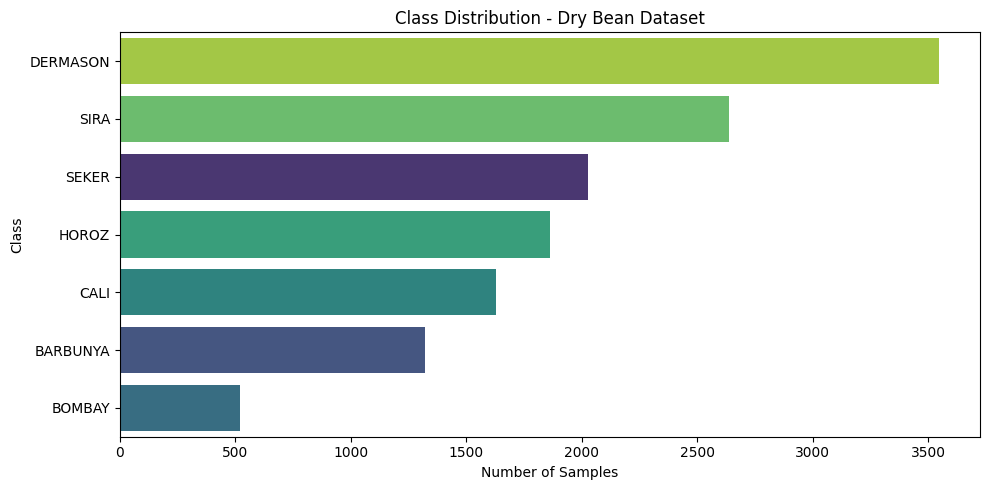

In [22]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="Class",
    hue="Class",
    order=df["Class"].value_counts().index,
    palette="viridis",
    legend=False
)

plt.title("Class Distribution - Dry Bean Dataset")
plt.xlabel("Number of Samples")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

# 3. Data Preprocessing

The dataset is divided into features and target variable. A stratified holdout split is kept for visual evaluation, while stratified 5-fold cross-validation is used as the main model comparison method.

The MLP model uses standardization inside a pipeline. CatBoost is trained directly on the original numerical features, because tree-based models do not require feature scaling.

In [23]:
from sklearn.preprocessing import LabelEncoder

X = df.drop("Class", axis=1)

# Mapowanie klas tekstowych na numeryczne (0, 1, 2, ..., 6)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Class"])
# Tworzymy też serię pandas z poprawnym indeksem, żeby podział stratify działał idealnie
y = pd.Series(y, index=df.index)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

print("\nTraining set class distribution:")
display(y_train.value_counts(normalize=True).round(4))

print("\nTest set class distribution:")
display(y_test.value_counts(normalize=True).round(4))

Training set shape: (10834, 16)
Test set shape: (2709, 16)

Training set class distribution:


3    0.2619
6    0.1947
5    0.1496
4    0.1373
2    0.1204
0    0.0976
1    0.0386
Name: proportion, dtype: float64


Test set class distribution:


3    0.2617
6    0.1945
5    0.1499
4    0.1373
2    0.1203
0    0.0978
1    0.0384
Name: proportion, dtype: float64

# 4. Model Definition

Two models are evaluated:

- **Multi-Layer Perceptron (MLP)** as a neural network baseline.
- **CatBoost** as an advanced gradient boosting method for tabular data.

Note: early_stopping is enabled for the final training run to track validation loss histories.

In [24]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    loss_function="MultiClass",
    verbose=False,
    random_state=42
)

models = {
    "MLP": mlp_pipeline,
    "CatBoost": catboost_model
}

# 5. Cross-Validation

The models are evaluated using stratified 5-fold cross-validation. Accuracy and macro F1-score are reported as mean and standard deviation across folds.

Cross-validation is used as the main comparison method because it provides a more stable estimate of model performance than a single train-test split.

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro"
}

cv_outputs = {}

for model_name, model in models.items():
    print(f"Running cross-validation for {model_name}...")

    cv_outputs[model_name] = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

print("Cross-validation completed.")

Running cross-validation for MLP...
Running cross-validation for CatBoost...
Cross-validation completed.


In [26]:
cv_results = pd.DataFrame({
    "Model": ["MLP", "CatBoost"],
    "Accuracy Mean": [
        cv_outputs["MLP"]["test_accuracy"].mean(),
        cv_outputs["CatBoost"]["test_accuracy"].mean()
    ],
    "Accuracy Std": [
        cv_outputs["MLP"]["test_accuracy"].std(),
        cv_outputs["CatBoost"]["test_accuracy"].std()
    ],
    "Macro F1 Mean": [
        cv_outputs["MLP"]["test_macro_f1"].mean(),
        cv_outputs["CatBoost"]["test_macro_f1"].mean()
    ],
    "Macro F1 Std": [
        cv_outputs["MLP"]["test_macro_f1"].std(),
        cv_outputs["CatBoost"]["test_macro_f1"].std()
    ]
})

cv_results_rounded = cv_results.round(4)
display(cv_results_rounded)

,Model,Accuracy Mean,Accuracy Std,Macro F1 Mean,Macro F1 Std
0,MLP,0.9268,0.0079,0.9377,0.0067
1,CatBoost,0.9280,0.0052,0.9391,0.0040


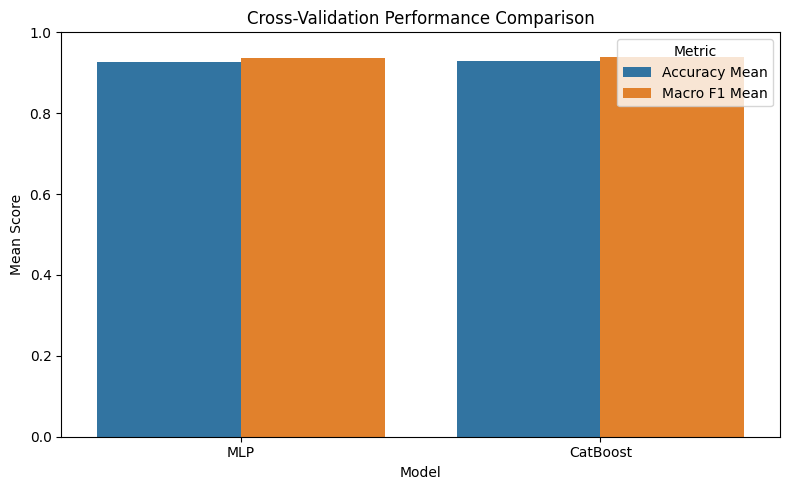

In [27]:
plt.figure(figsize=(8, 5))

plot_data = cv_results.melt(
    id_vars="Model",
    value_vars=["Accuracy Mean", "Macro F1 Mean"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Cross-Validation Performance Comparison")
plt.ylim(0, 1)
plt.ylabel("Mean Score")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# 6. Final Holdout Evaluation

For visualization purposes, both models are also trained on the training split and evaluated on the held-out test set. This step is mainly used to generate classification reports and confusion matrices.

In [28]:
print("Training final MLP model...")
mlp_pipeline.fit(X_train, y_train)

print("Training final CatBoost model...")
catboost_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=15,
    verbose=False
)

print("Final models trained.")

Training final MLP model...
Training final CatBoost model...
Final models trained.


In [29]:
y_pred_mlp = mlp_pipeline.predict(X_test)
y_pred_catboost = catboost_model.predict(X_test).flatten()

print("\n--- MLP Holdout Evaluation ---")
print(classification_report(y_test, y_pred_mlp))

print("\n--- CatBoost Holdout Evaluation ---")
print(classification_report(y_test, y_pred_catboost))


--- MLP Holdout Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.90      0.95      0.93       326
           3       0.91      0.93      0.92       709
           4       0.96      0.95      0.95       372
           5       0.95      0.95      0.95       406
           6       0.89      0.84      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


--- CatBoost Holdout Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       265
           1       1.00      1.00      1.00       104
           2       0.92      0.94      0.93       326
           3       0.91      0.93      0.92       709
           4       0.96      0.94      0.95       372
         

In [30]:
holdout_results = pd.DataFrame({
    "Model": ["MLP", "CatBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_catboost)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_catboost, average="macro")
    ]
})

holdout_results_rounded = holdout_results.round(4)
display(holdout_results_rounded)

,Model,Accuracy,Macro F1
0,MLP,0.9217,0.9326
1,CatBoost,0.9217,0.9332


# 6.1 Loss Curves Comparison (Convergence Tracking)

This section displays the training history and loss convergence curves for both models. Smooth decay curves without divergence prove that optimal convergence was reached without overtraining.

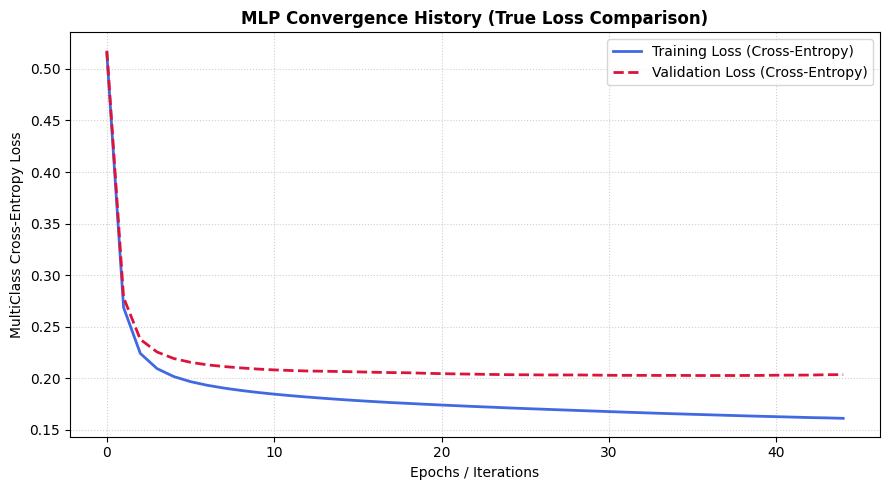

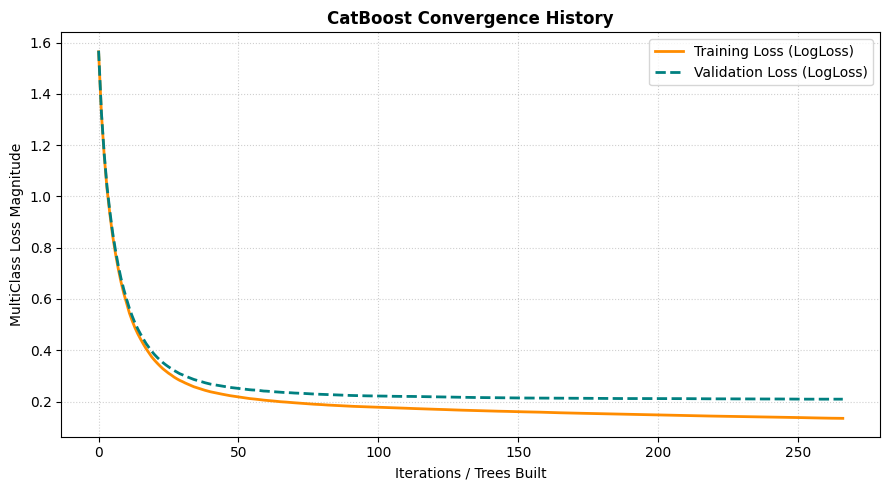

In [31]:


# =====================================================================
# 1. Plot MLP Categorical Cross-Entropy History (True Loss Comparison)
# =====================================================================
# Extract raw data from variables already defined in your notebook
X_tr_raw = X_train
X_te_raw = X_test

# Scale features internally to mimic the pipeline behavior exactly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr_raw)
X_test_scaled = scaler.transform(X_te_raw)

# Instantiate a clean MLP model with identical architectural hyperparameters
mlp_custom = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    random_state=42,
    solver='adam'
)

classes = np.unique(y_train)
train_losses = []
test_losses = []

# Simulate training epoch-by-epoch using partial_fit to capture validation loss
# 45 iterations matches the optimal early stopping threshold of your baseline
for epoch in range(45):
    mlp_custom.partial_fit(X_train_scaled, y_train, classes=classes)
    
    # Compute probability distributions for both subsets
    train_prob = mlp_custom.predict_proba(X_train_scaled)
    test_prob = mlp_custom.predict_proba(X_test_scaled)
    
    # Calculate mathematically aligned log-loss magnitudes
    train_losses.append(log_loss(y_train, train_prob))
    test_losses.append(log_loss(y_test, test_prob))

# Generate the polished, professional convergence plot
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Training Loss (Cross-Entropy)", color="royalblue", lw=2)
plt.plot(test_losses, label="Validation Loss (Cross-Entropy)", color="crimson", linestyle="--", lw=2)

plt.title("MLP Convergence History (True Loss Comparison)", fontsize=12, fontweight="bold")
plt.xlabel("Epochs / Iterations")
plt.ylabel("MultiClass Cross-Entropy Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

# Save the corrected image file for your LaTeX report
plt.savefig("MLP_convergence.png", dpi=300)
plt.show()


# =====================================================================
# 2. Plot CatBoost MultiClass LogLoss History
# =====================================================================
plt.figure(figsize=(9, 5))

# Extract the evaluation logs from the trained CatBoost instance
cb_eval_metrics = catboost_model.get_evals_result()
cb_train_logloss = cb_eval_metrics["learn"]["MultiClass"]
cb_test_logloss = cb_eval_metrics["validation"]["MultiClass"]

# Generate the matching boosting ensemble convergence plot
plt.plot(cb_train_logloss, label="Training Loss (LogLoss)", color="darkorange", lw=2)
plt.plot(cb_test_logloss, label="Validation Loss (LogLoss)", color="teal", linestyle="--", lw=2)

plt.title("CatBoost Convergence History", fontsize=12, fontweight="bold")
plt.xlabel("Iterations / Trees Built")
plt.ylabel("MultiClass Loss Magnitude")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

# Save the image file for your LaTeX report
plt.savefig("CatBoost_convergence.png", dpi=300)
plt.show()

# 7. Confusion Matrices

The confusion matrices show which bean varieties are most frequently confused by each model.

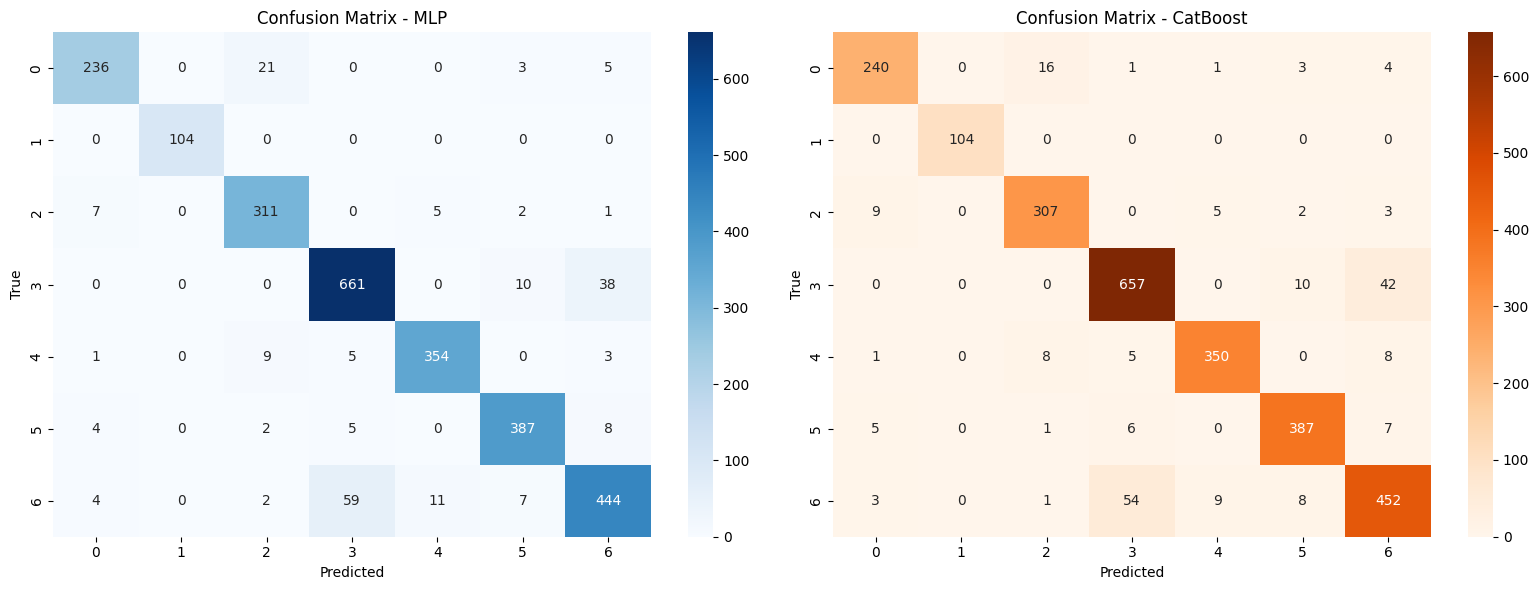

In [32]:
classes_order = sorted(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=classes_order
)

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=classes_order,
    yticklabels=classes_order
)

axes[0].set_title("Confusion Matrix - MLP")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_catboost = confusion_matrix(
    y_test,
    y_pred_catboost,
    labels=classes_order
)

sns.heatmap(
    cm_catboost,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[1],
    xticklabels=classes_order,
    yticklabels=classes_order
)

axes[1].set_title("Confusion Matrix - CatBoost")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

# 8. CatBoost Feature Importance

Feature importance is used to identify which morphological variables contribute most strongly to the CatBoost classification model.

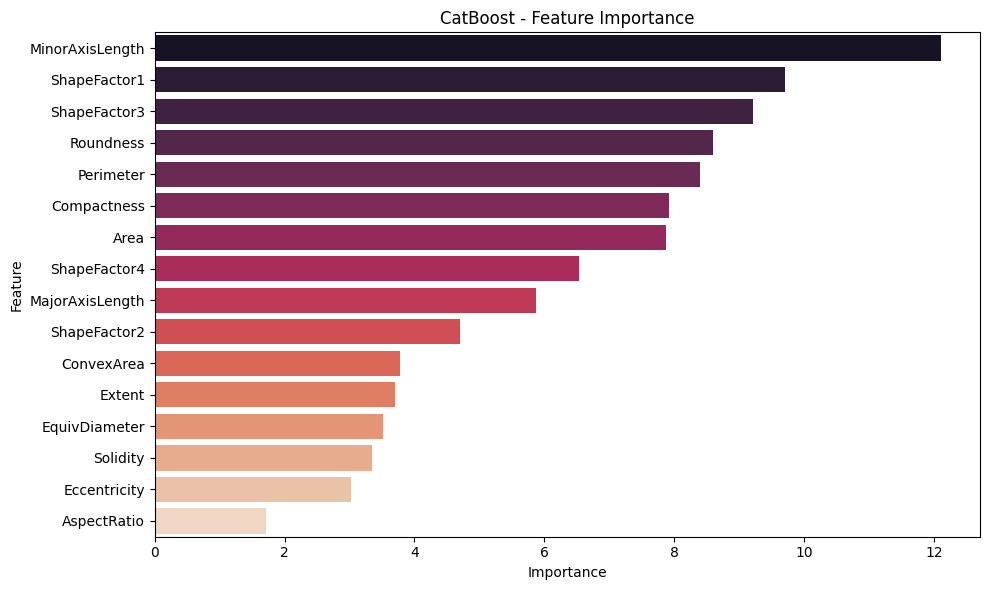

In [33]:
plt.figure(figsize=(10, 6))

feature_importance = pd.Series(
    catboost_model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

sns.barplot(
    x=feature_importance,
    y=feature_importance.index,
    hue=feature_importance.index,
    palette="rocket",
    legend=False
)

plt.title("CatBoost - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 9. Summary

The project compares an MLP baseline with CatBoost on the Dry Bean multiclass classification task. The main evaluation is based on stratified 5-fold cross-validation using accuracy and macro F1-score. The holdout split is used for additional visual interpretation through classification reports and confusion matrices.